# Figure 1: Metabolic Rate Distribution by Vessel and Time of Day ('Environment')

This notebook isolates the code needed to reproduce the Figure 1 box-and-whisker chart


The data file required is batch_summary.csv which is produced in the notebook A_batch_respirometry_final.ipynb

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them. These trials
# yielded negative respiration rates and are not included in the main analysis, but they are included 
# here for completeness. During those trials, our seawater filter clogged and we used unfiltered seawater, 
# which likely introduced contaminants that affected the calculation of respiration rates.

use_unfiltered = False

# Locate the processed batch summary from common notebook working directories.
candidate_paths = [
    Path.cwd() / "../data/processed/batch_summary.csv",
    Path.cwd() / "data/processed/batch_summary.csv",
    Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv"),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/batch_summary.csv")

agg_df = pd.read_csv(data_path)
print(f"Loaded {len(agg_df)} rows from {data_path}")

Loaded 71 rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


In [3]:
# Figure style for publication plots (Avenir-first)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Avenir', 'Avenir Next', 'Arial', 'DejaVu Sans'],
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.6,
    'xtick.major.width': 1.4,
    'ytick.major.width': 1.4,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

print('Figure style applied (Avenir-first font stack).')

Figure style applied (Avenir-first font stack).



Summary statistics by group:


count      mean       std       min       max
vessel   environment                                               
cylinder night            8  5.844194  2.439238  2.897411  8.546660
medium   night            6  3.614779  1.015635  2.521120  5.398751
small    day             18  1.181223  0.696188  0.375336  2.995435
         night           26  2.097811  1.084139  0.384284  4.356231

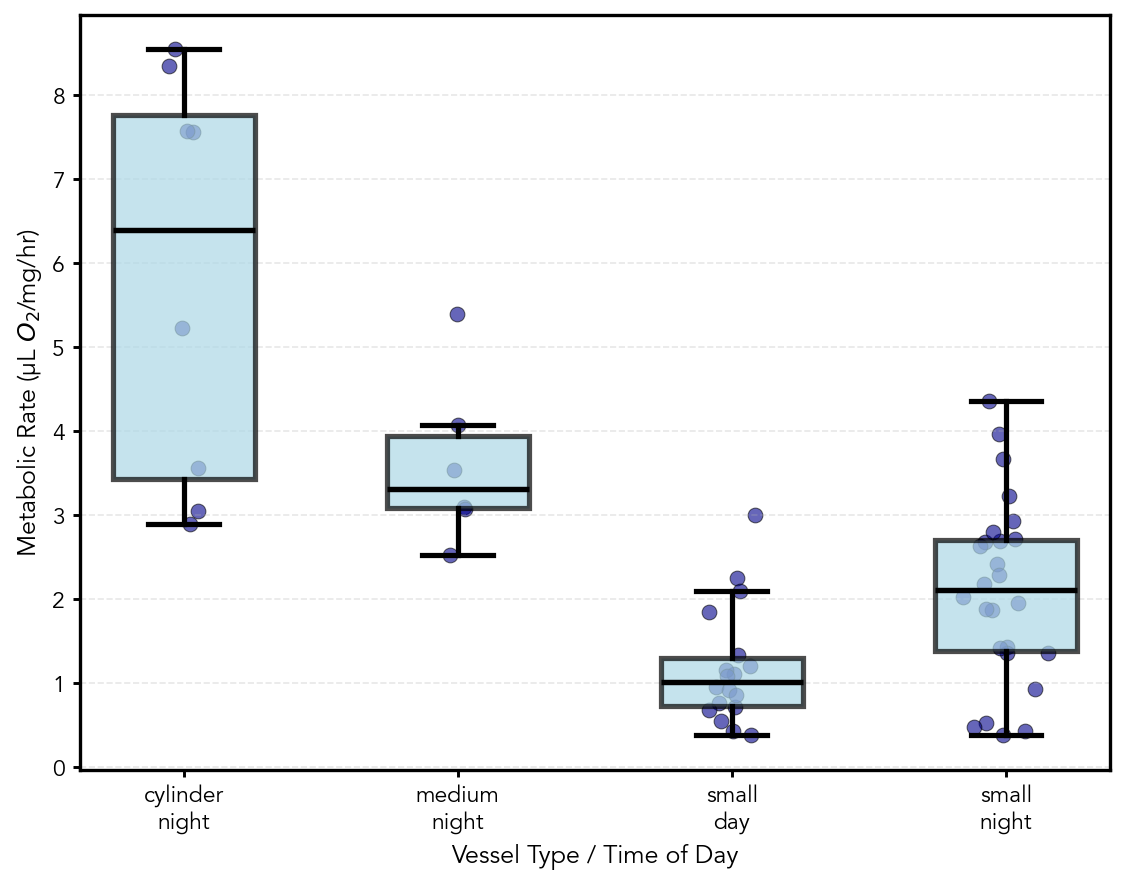

In [12]:
if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle.
    plot_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

    # Group by vessel and environment if those columns exist.
    group_cols = [col for col in ['vessel', 'environment'] if col in plot_df.columns]

    if group_cols:
        stats = plot_df.groupby(group_cols)['RMR'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)

        plot_df['group'] = plot_df['vessel'] + '\n' + plot_df['environment']
        groups = sorted(plot_df['group'].unique())
        data_by_group = [plot_df[plot_df['group'] == g]['RMR'].values for g in groups]

        # Keep boxes narrow but place category centers closer together.
        positions = np.arange(len(groups)) * 0.58

        # Make canvas width proportional to number of groups so whitespace stays compact.
        fig_width = max(6.5, 1.55 * len(groups) + 1.4)
        fig, ax = plt.subplots(figsize=(fig_width, 6))

        bp = ax.boxplot(
            data_by_group,
            positions=positions,
            tick_labels=groups,
            patch_artist=True,
            widths=0.30,
            showfliers=False,
            boxprops=dict(linewidth=2.5, color='black'),
            whiskerprops=dict(linewidth=2.5, color='black'),
            capprops=dict(linewidth=2.5, color='black'),
            medianprops=dict(linewidth=2.6, color='black'),
        )
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)

        for i, group in enumerate(groups):
            y_data = plot_df[plot_df['group'] == group]['RMR'].values
            x_data = np.random.normal(positions[i], 0.03, size=len(y_data))
            ax.scatter(
                x_data,
                y_data,
                alpha=0.6,
                s=50,
                c='darkblue',
                edgecolors='black',
                linewidth=0.5,
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(groups)
        ax.set_ylabel('Metabolic Rate (µL $O_2$/mg/hr)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vessel Type / Time of Day', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Tighten side whitespace around first and last categories.
        ax.set_xlim(positions[0] - 0.22, positions[-1] + 0.22)

        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()
    else:
        print("\nOverall statistics:")
        print(plot_df['RMR'].describe())
else:
    print('No data available for statistics.')